In [1]:
import argparse
import json
import csv
import glob

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch

import random
import monai
from monai.data import CacheDataset, DataLoader
import monai.transforms as transforms

import nibabel as nib

#import seaborn as sns
import matplotlib.pyplot as plt

from multiprocessing import Pool
from functools import partial

from monai.metrics import compute_iou, DiceMetric

/bettik/PROJECTS/pr-gin5_aini/fehrdelt/environments/ddpm_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#ROOT_DIR = "/home/fehrdelt/bettik/"

In [3]:
adc_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2/large/"
flair_anomaly_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/exp_3_2/large/"

In [7]:
adc_ano_maps = os.listdir(adc_anomaly_maps_folder)
adc_ano_maps = [f for f in adc_ano_maps if "seg" not in f]

flair_ano_maps = os.listdir(flair_anomaly_maps_folder)
flair_ano_maps = [f for f in flair_ano_maps if "seg" not in f]

In [8]:
combined_ano_maps = {}

In [9]:
for adc_map in tqdm(adc_ano_maps):
    patient_id = adc_map.split(".")[0]

    #print(patient_id)

    flair_map = f"{patient_id}.nii.gz"

    adc_ano_image = nib.load(os.path.join(adc_anomaly_maps_folder, adc_map))
    flair_ano_image = nib.load(os.path.join(flair_anomaly_maps_folder, flair_map))
    
    combined_map = (adc_ano_image.get_fdata() + flair_ano_image.get_fdata())/2

    nib.save(nib.Nifti1Image(combined_map, adc_ano_image.affine), f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps/{patient_id.split('_')[-1]}.nii.gz")
    
    combined_ano_maps[patient_id] = combined_map


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:16<00:00,  2.45it/s]


Visualise combined ano maps

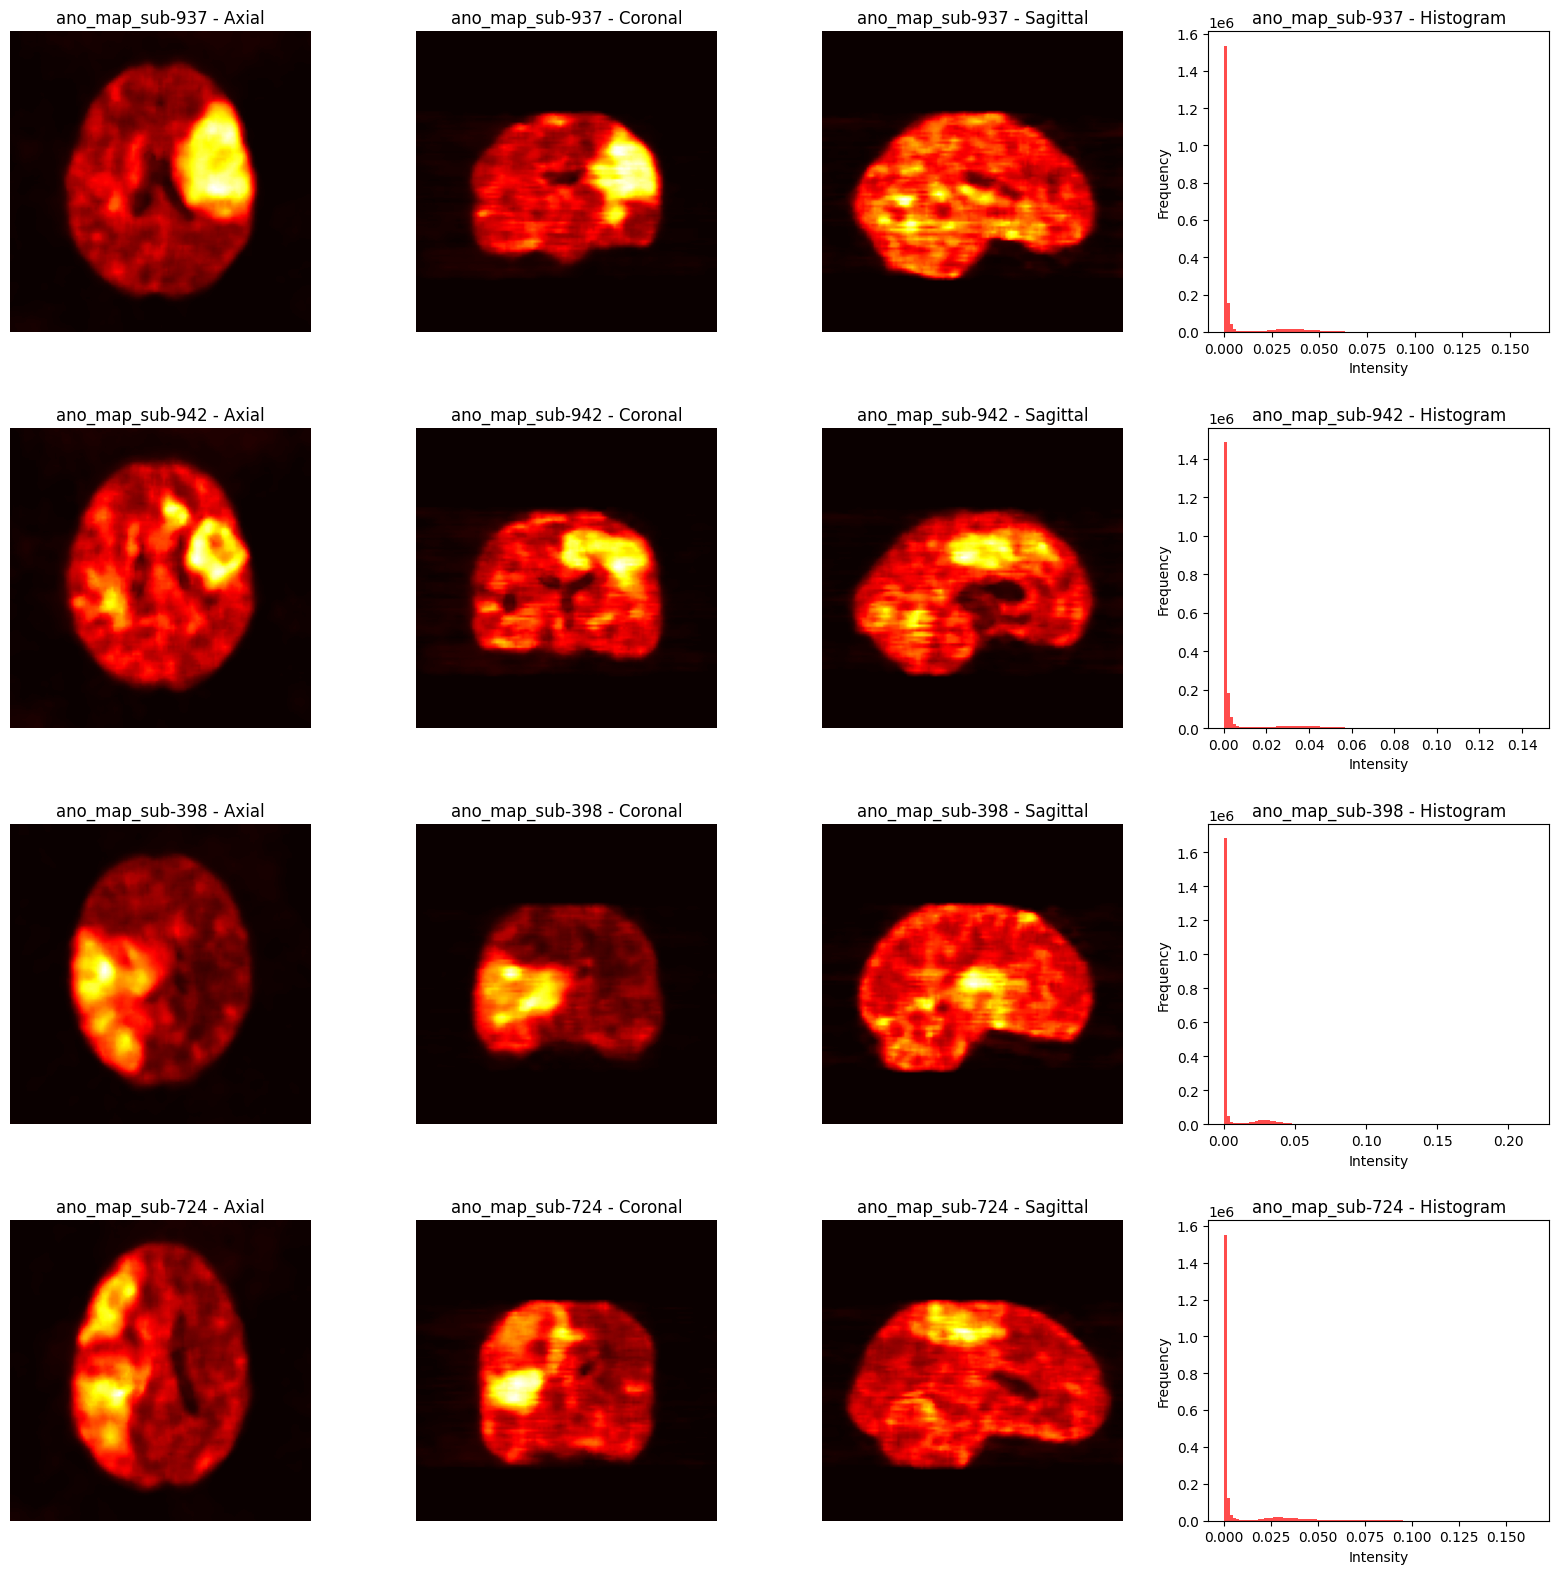

In [10]:
# Visualize middle slices of the first four combined anomaly maps with histograms
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

patient_ids = list(combined_ano_maps.keys())[:4]

for i, patient_id in enumerate(patient_ids):
    ano_map = combined_ano_maps[patient_id]
    
    # Get middle slice indices
    mid_axial = ano_map.shape[2] // 2
    mid_coronal = ano_map.shape[1] // 2
    mid_sagittal = ano_map.shape[0] // 2
    
    # Axial slice
    axes[i, 0].imshow(ano_map[:, :, mid_axial].T, cmap='hot', origin='lower')
    axes[i, 0].set_title(f'{patient_id} - Axial')
    axes[i, 0].axis('off')
    
    # Coronal slice
    axes[i, 1].imshow(ano_map[:, mid_coronal, :].T, cmap='hot', origin='lower')
    axes[i, 1].set_title(f'{patient_id} - Coronal')
    axes[i, 1].axis('off')
    
    # Sagittal slice
    axes[i, 2].imshow(ano_map[mid_sagittal, :, :].T, cmap='hot', origin='lower')
    axes[i, 2].set_title(f'{patient_id} - Sagittal')
    axes[i, 2].axis('off')
    
    # Histogram of the whole 3D image
    axes[i, 3].hist(ano_map.flatten(), bins=100, color='red', alpha=0.7)
    axes[i, 3].set_title(f'{patient_id} - Histogram')
    axes[i, 3].set_xlabel('Intensity')
    axes[i, 3].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**optim seuil sur 1er groupe**

In [11]:
chronic_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_chronic_registered/"
acute_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_acute_registered/"
combined_masks_folder = f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_combined_registered/"

In [12]:
chronic_masks_paths = os.listdir(chronic_masks_folder)
acute_masks_paths = os.listdir(acute_masks_folder)
combined_masks_paths = os.listdir(combined_masks_folder)  # Assuming same names for chronic and acute masks

In [13]:
combined_ano_maps_folder = f"{ROOT_DIR}datasets/anomaly_maps/combined_ano_maps/"
combined_ano_maps_paths = os.listdir(combined_ano_maps_folder)
combined_ano_maps_paths = sorted(combined_ano_maps_paths)
print(combined_ano_maps_paths)

['sub-366.nii.gz', 'sub-370.nii.gz', 'sub-374.nii.gz', 'sub-398.nii.gz', 'sub-400.nii.gz', 'sub-422.nii.gz', 'sub-433.nii.gz', 'sub-443.nii.gz', 'sub-446.nii.gz', 'sub-457.nii.gz', 'sub-463.nii.gz', 'sub-466.nii.gz', 'sub-525.nii.gz', 'sub-53.nii.gz', 'sub-530.nii.gz', 'sub-543.nii.gz', 'sub-56.nii.gz', 'sub-572.nii.gz', 'sub-631.nii.gz', 'sub-634.nii.gz', 'sub-651.nii.gz', 'sub-661.nii.gz', 'sub-692.nii.gz', 'sub-698.nii.gz', 'sub-724.nii.gz', 'sub-751.nii.gz', 'sub-760.nii.gz', 'sub-761.nii.gz', 'sub-768.nii.gz', 'sub-776.nii.gz', 'sub-791.nii.gz', 'sub-8.nii.gz', 'sub-803.nii.gz', 'sub-866.nii.gz', 'sub-877.nii.gz', 'sub-937.nii.gz', 'sub-942.nii.gz', 'sub-946.nii.gz', 'sub-959.nii.gz', 'sub-960.nii.gz']


In [33]:
print(adc_ano_maps)
adc_ano_maps = sorted(adc_ano_maps)
print(adc_ano_maps)

['ano_map_sub-366.nii.gz', 'ano_map_sub-370.nii.gz', 'ano_map_sub-374.nii.gz', 'ano_map_sub-398.nii.gz', 'ano_map_sub-400.nii.gz', 'ano_map_sub-422.nii.gz', 'ano_map_sub-433.nii.gz', 'ano_map_sub-443.nii.gz', 'ano_map_sub-446.nii.gz', 'ano_map_sub-457.nii.gz', 'ano_map_sub-463.nii.gz', 'ano_map_sub-466.nii.gz', 'ano_map_sub-525.nii.gz', 'ano_map_sub-53.nii.gz', 'ano_map_sub-530.nii.gz', 'ano_map_sub-543.nii.gz', 'ano_map_sub-56.nii.gz', 'ano_map_sub-572.nii.gz', 'ano_map_sub-631.nii.gz', 'ano_map_sub-634.nii.gz', 'ano_map_sub-651.nii.gz', 'ano_map_sub-661.nii.gz', 'ano_map_sub-692.nii.gz', 'ano_map_sub-698.nii.gz', 'ano_map_sub-724.nii.gz', 'ano_map_sub-751.nii.gz', 'ano_map_sub-760.nii.gz', 'ano_map_sub-761.nii.gz', 'ano_map_sub-768.nii.gz', 'ano_map_sub-776.nii.gz', 'ano_map_sub-791.nii.gz', 'ano_map_sub-8.nii.gz', 'ano_map_sub-803.nii.gz', 'ano_map_sub-866.nii.gz', 'ano_map_sub-877.nii.gz', 'ano_map_sub-937.nii.gz', 'ano_map_sub-942.nii.gz', 'ano_map_sub-946.nii.gz', 'ano_map_sub-95

In [14]:
patient_ids_to_test = [os.path.basename(path).split(".")[0] for path in combined_ano_maps_paths]
print(patient_ids_to_test)

['sub-366', 'sub-370', 'sub-374', 'sub-398', 'sub-400', 'sub-422', 'sub-433', 'sub-443', 'sub-446', 'sub-457', 'sub-463', 'sub-466', 'sub-525', 'sub-53', 'sub-530', 'sub-543', 'sub-56', 'sub-572', 'sub-631', 'sub-634', 'sub-651', 'sub-661', 'sub-692', 'sub-698', 'sub-724', 'sub-751', 'sub-760', 'sub-761', 'sub-768', 'sub-776', 'sub-791', 'sub-8', 'sub-803', 'sub-866', 'sub-877', 'sub-937', 'sub-942', 'sub-946', 'sub-959', 'sub-960']


In [35]:


adc_maps_transforms = transforms.Compose([
    transforms.LoadImage(),
    transforms.EnsureChannelFirst(),
])

# Create MONAI Dataset and DataLoader
adc_list_maps = [os.path.join(adc_anomaly_maps_folder, path) for path in adc_ano_maps]
adc_maps_dataset = CacheDataset(data=adc_list_maps, transform=adc_maps_transforms)
adc_maps_dataloader = DataLoader(adc_maps_dataset, batch_size=2, shuffle=False, num_workers=0)

Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:02<00:00, 15.66it/s]


In [36]:

combined_maps_transforms = transforms.Compose([
    transforms.LoadImage(),
    transforms.EnsureChannelFirst(),
])

# Create MONAI Dataset and DataLoader
list_maps = [os.path.join(combined_ano_maps_folder, path) for path in combined_ano_maps_paths]
combined_maps_dataset = CacheDataset(data=list_maps, transform=combined_maps_transforms)

combined_maps_dataloader = DataLoader(combined_maps_dataset, batch_size=2, shuffle=False, num_workers=0)

Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:04<00:00,  8.74it/s]


In [37]:


# Create list of dictionaries for MONAI Dataset

combined_masks_transforms = transforms.Compose([
    transforms.LoadImage(),
    transforms.EnsureChannelFirst(),
])

# Create MONAI Dataset and DataLoader
combined_masks_to_keep = [os.path.join(combined_masks_folder, path) for path in combined_ano_maps_paths]

combined_masks_dataset = CacheDataset(data=combined_masks_to_keep, transform=combined_masks_transforms)

combined_masks_dataloader = DataLoader(combined_masks_dataset, batch_size=2, shuffle=False, num_workers=0)

Loading dataset:   0%|                                                                                                                                                                        | 0/40 [00:00<?, ?it/s]

Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 26.88it/s]


In [38]:
print(list_maps)
print(combined_masks_to_keep)
print(adc_list_maps)

['/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-366.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-370.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-374.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-398.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-400.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-422.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-433.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-443.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-446.nii.gz', '/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/anomaly_maps/combined_ano_maps/sub-457.nii.gz', '/bettik/PROJECTS/pr-gin5_ain

In [18]:
#TODO il faut que ça corresponde en one to one

ano_map shape: (128, 128, 128), mask shape: (128, 128, 128)


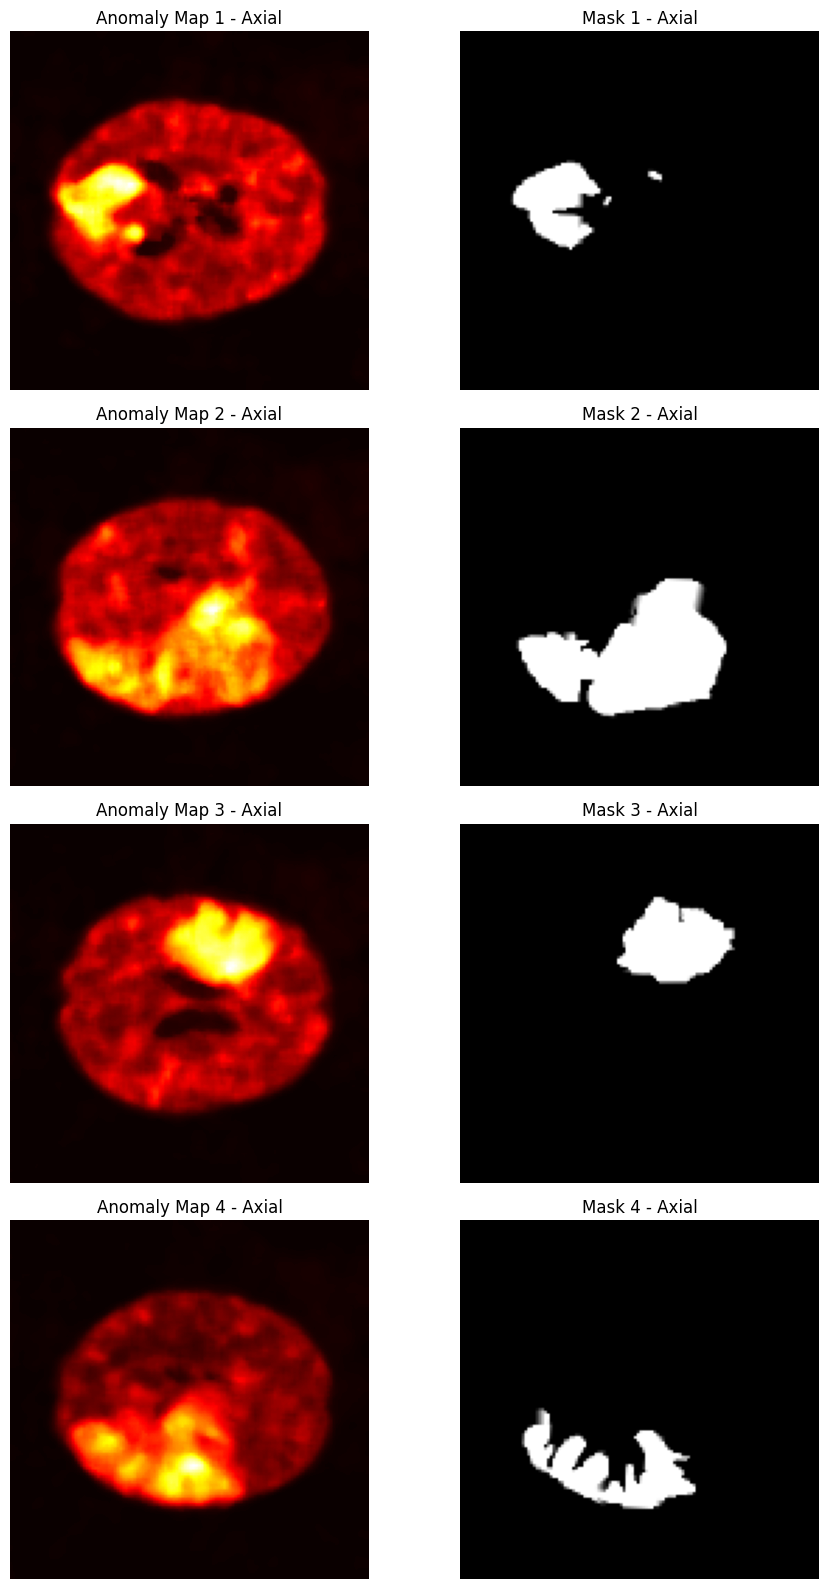

In [19]:
# Display first 4 images from combined_maps_dataloader and their corresponding masks
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

combined_maps_iter = iter(combined_maps_dataloader)
combined_masks_iter = iter(combined_masks_dataloader)

# Get first 2 batches (batch_size=2, so 2 batches = 4 images)
maps_batch1 = next(combined_maps_iter)
masks_batch1 = next(combined_masks_iter)
maps_batch2 = next(combined_maps_iter)
masks_batch2 = next(combined_masks_iter)

all_maps = torch.cat([maps_batch1, maps_batch2], dim=0)
all_masks = torch.cat([masks_batch1, masks_batch2], dim=0)

for i in range(4):
    ano_map = all_maps[i, 0].numpy()
    mask = all_masks[i, 0].numpy()

    if i == 0:
        print(f'ano_map shape: {ano_map.shape}, mask shape: {mask.shape}')
    
    mid_slice = ano_map.shape[2] // 2
    
    axes[i, 0].imshow(ano_map[:, :, mid_slice], cmap='hot', origin='lower')
    axes[i, 0].set_title(f'Anomaly Map {i+1} - Axial')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask[:, :, mid_slice], cmap='gray', origin='lower')
    axes[i, 1].set_title(f'Mask {i+1} - Axial')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [20]:
dm = DiceMetric(reduction="sum")

In [21]:
dice_scores_combined = []

In [22]:
thresholds_to_try = np.linspace(0.01, 0.08, 30)

**utiliser DICE de Monai**

In [41]:
dice_scores_combined = {}
dice_scores_std_combined = {}

for threshold in tqdm(thresholds_to_try):

    this_dice_score = []

    for ano_map, ano_mask in zip(combined_maps_dataloader, combined_masks_dataloader):
                
        ano_mask[ano_mask > 0.5] = 1

        combined_segmentation = (ano_map > threshold)

        combined_dice_score = dm(combined_segmentation, ano_mask).flatten()
        
        combined_dice_score = combined_dice_score[~np.isnan(combined_dice_score)]
        
        this_dice_score.append(combined_dice_score)
            
        
    dice_scores_combined[threshold] = np.mean(this_dice_score)
    dice_scores_std_combined[threshold] = np.std(this_dice_score)

    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:09<00:00,  3.29it/s]


In [42]:
max_threshold = max(dice_scores_combined, key=dice_scores_combined.get)
max_dice = dice_scores_combined[max_threshold]
print(f"Best Dice Score: {max_dice} at threshold: {max_threshold}")
print(f"Standard Deviation of Dice Score at best threshold: {dice_scores_std_combined[max_threshold]}")

Best Dice Score: 0.6793955564498901 at threshold: 0.06310344827586208
Standard Deviation of Dice Score at best threshold: 0.17687320709228516


### now do the same thing with only the adc map and compare if the combined maps really improve the dice score

In [43]:
dice_scores_adc = {}
dice_scores_std_adc = {}

for threshold in tqdm(thresholds_to_try):

    this_dice_score = []

    for ano_map, ano_mask in zip(adc_maps_dataloader, combined_masks_dataloader):
                
        ano_mask[ano_mask > 0.5] = 1

        adc_segmentation = (ano_map > threshold)

        adc_dice_score = dm(adc_segmentation, ano_mask).flatten()
        
        adc_dice_score = adc_dice_score[~np.isnan(adc_dice_score)]
        
        this_dice_score.append(adc_dice_score)
            
        
    dice_scores_adc[threshold] = np.mean(this_dice_score)
    dice_scores_std_adc[threshold] = np.std(this_dice_score)

    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:09<00:00,  3.26it/s]


In [45]:
max_threshold = max(dice_scores_adc, key=dice_scores_adc.get)
max_dice = dice_scores_adc[max_threshold]
print(f"Best Dice Score: {max_dice} at threshold: {max_threshold}")
print(f"Standard Deviation of Dice Score at best threshold: {dice_scores_std_adc[max_threshold]}")

Best Dice Score: 0.6012141704559326 at threshold: 0.07758620689655173
Standard Deviation of Dice Score at best threshold: 0.2039753943681717


**!!! Attention faire pareil avec FLAIR maps seuls pour vraiment pouvoir comparer**